# Smoker Prediction

## Data Loading and Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
train_df = pd.read_csv('../data/train/train.csv', index_col='id')
test_df = pd.read_csv('../data/test/test.csv', index_col='id')

## EDA

In [3]:
train_df.head()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
id,,,,,,,,,,,,,,,,,,,,,
0,55,165,60,81.0,0.5,0.6,1,1,135,87,...,40,75,16.5,1,1.0,22,25,27,0,1
1,70,165,65,89.0,0.6,0.7,2,2,146,83,...,57,126,16.2,1,1.1,27,23,37,1,0
2,20,170,75,81.0,0.4,0.5,1,1,118,75,...,45,93,17.4,1,0.8,27,31,53,0,1
3,35,180,95,105.0,1.5,1.2,1,1,131,88,...,38,102,15.9,1,1.0,20,27,30,1,0
4,30,165,60,80.5,1.5,1.0,1,1,121,76,...,44,93,15.4,1,0.8,19,13,17,0,1


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 159256 entries, 0 to 159255
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   age                  159256 non-null  int64  
 1   height(cm)           159256 non-null  int64  
 2   weight(kg)           159256 non-null  int64  
 3   waist(cm)            159256 non-null  float64
 4   eyesight(left)       159256 non-null  float64
 5   eyesight(right)      159256 non-null  float64
 6   hearing(left)        159256 non-null  int64  
 7   hearing(right)       159256 non-null  int64  
 8   systolic             159256 non-null  int64  
 9   relaxation           159256 non-null  int64  
 10  fasting blood sugar  159256 non-null  int64  
 11  Cholesterol          159256 non-null  int64  
 12  triglyceride         159256 non-null  int64  
 13  HDL                  159256 non-null  int64  
 14  LDL                  159256 non-null  int64  
 15  hemoglobin           1

In [5]:
train_df.describe()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
count,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,...,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000,159256.000000
mean,44.306626,165.266929,67.143662,83.001990,1.005798,1.000989,1.023974,1.023421,122.503648,76.874071,...,55.852684,114.607682,14.796965,1.074233,0.892764,25.516853,26.550296,36.216004,0.197996,0.437365
std,11.842286,8.818970,12.586198,8.957937,0.402113,0.392299,0.152969,0.151238,12.729315,8.994642,...,13.964141,28.158931,1.431213,0.347856,0.179346,9.464882,17.753070,31.204643,0.398490,0.496063
min,20.000000,135.000000,30.000000,51.000000,0.100000,0.100000,1.000000,1.000000,77.000000,44.000000,...,9.000000,1.000000,4.900000,1.000000,0.100000,6.000000,1.000000,2.000000,0.000000,0.000000
25%,40.000000,160.000000,60.000000,77.000000,0.800000,0.800000,1.000000,1.000000,114.000000,70.000000,...,45.000000,95.000000,13.800000,1.000000,0.800000,20.000000,16.000000,18.000000,0.000000,0.000000
50%,40.000000,165.000000,65.000000,83.000000,1.000000,1.000000,1.000000,1.000000,121.000000,78.000000,...,54.000000,114.000000,15.000000,1.000000,0.900000,24.000000,22.000000,27.000000,0.000000,0.000000
75%,55.000000,170.000000,75.000000,89.000000,1.200000,1.200000,1.000000,1.000000,130.000000,82.000000,...,64.000000,133.000000,15.800000,1.000000,1.000000,29.000000,32.000000,44.000000,0.000000,1.000000
max,85.000000,190.000000,130.000000,127.000000,9.900000,9.900000,2.000000,2.000000,213.000000,133.000000,...,136.000000,1860.000000,21.000000,6.000000,9.900000,778.000000,2914.000000,999.000000,1.000000,1.000000


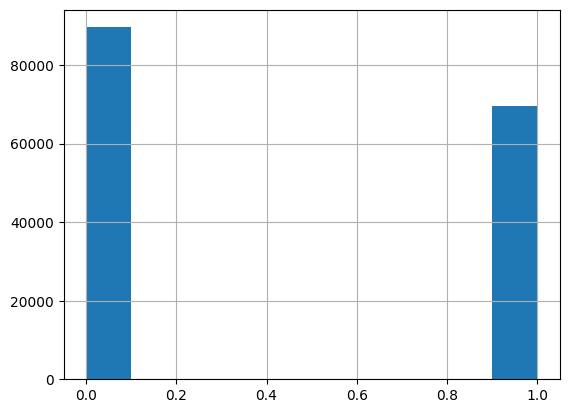

In [6]:
train_df['smoking'].hist()
plt.show()

## Feature Engineering 

In [7]:
train_df['BMI'] =  train_df['weight(kg)'] / (train_df['height(cm)']/100)**2
train_df['WHtR'] = train_df['waist(cm)'] / train_df['height(cm)']
train_df['eyesight'] = train_df['eyesight(left)'] + train_df['eyesight(right)'] / 2

train_df.drop(['weight(kg)', 'height(cm)', 'waist(cm)', 'eyesight(left)', 'eyesight(right)', 
               'hearing(left)', 'hearing(right)'], 
              axis=1, inplace=True)

In [8]:
corr_matrix = train_df.corr()

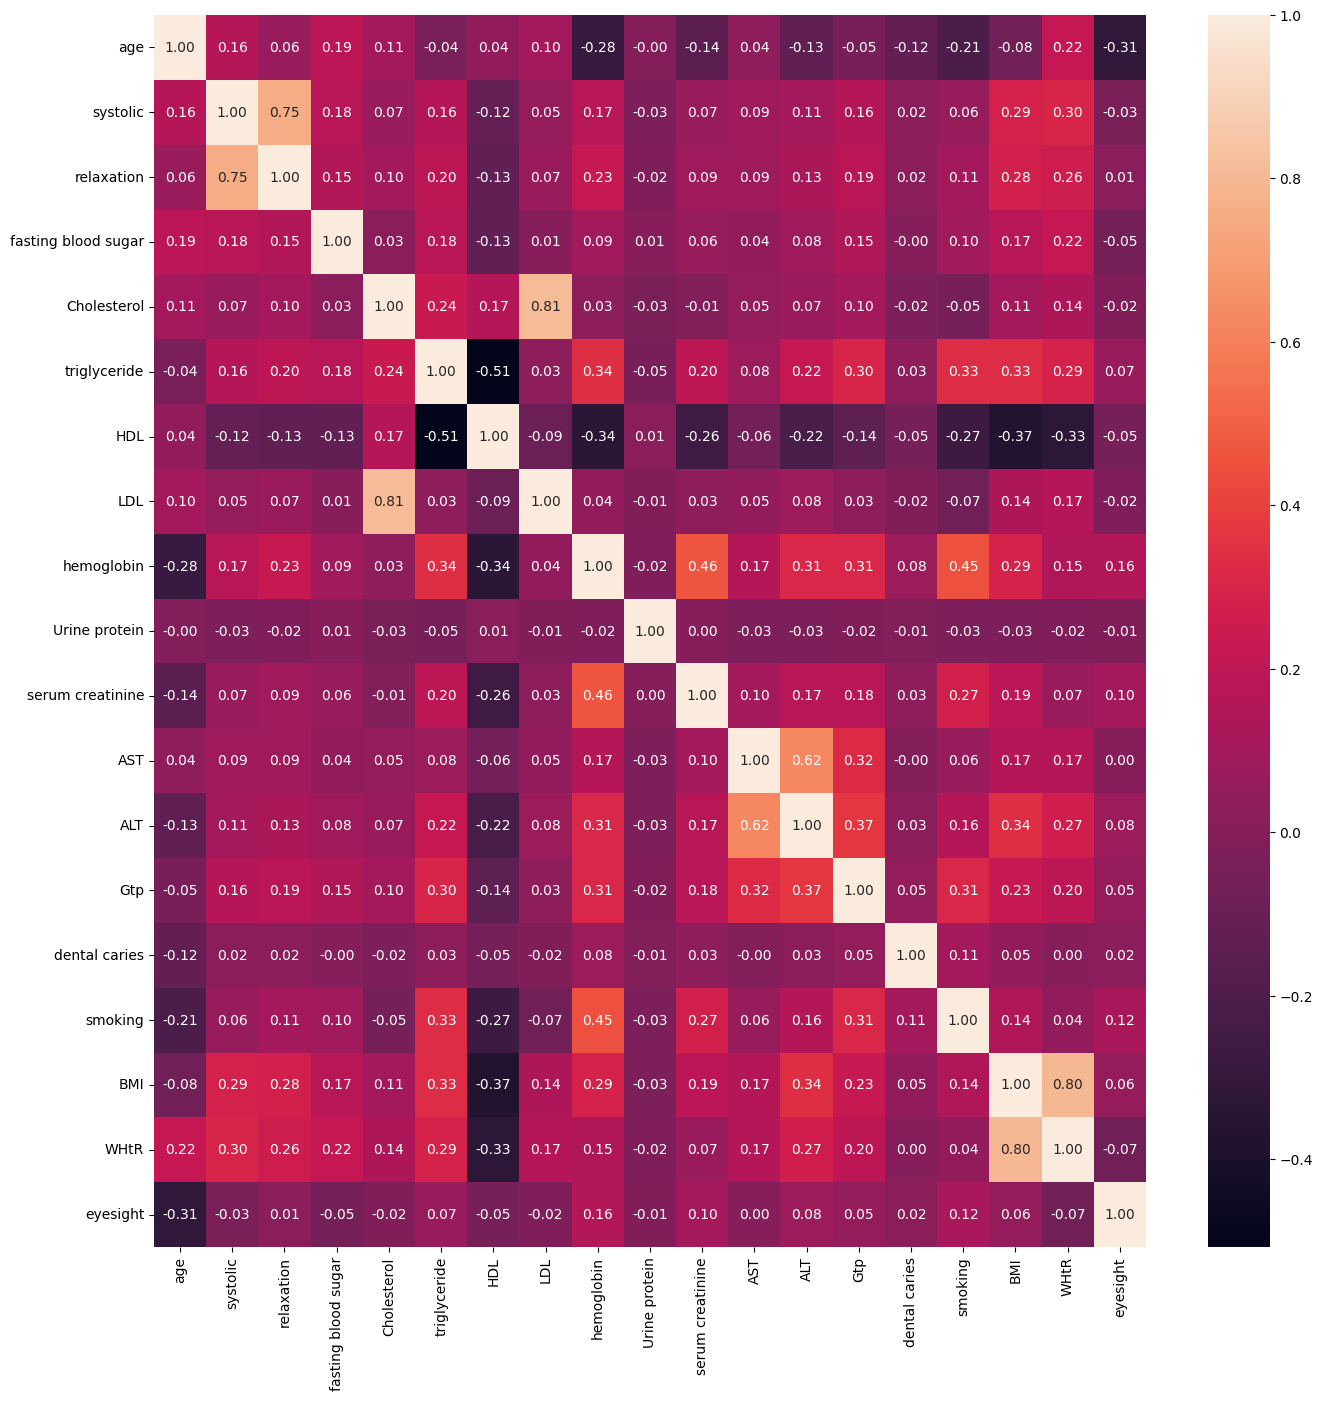

In [9]:
plt.figure(figsize=(16, 16))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.show()

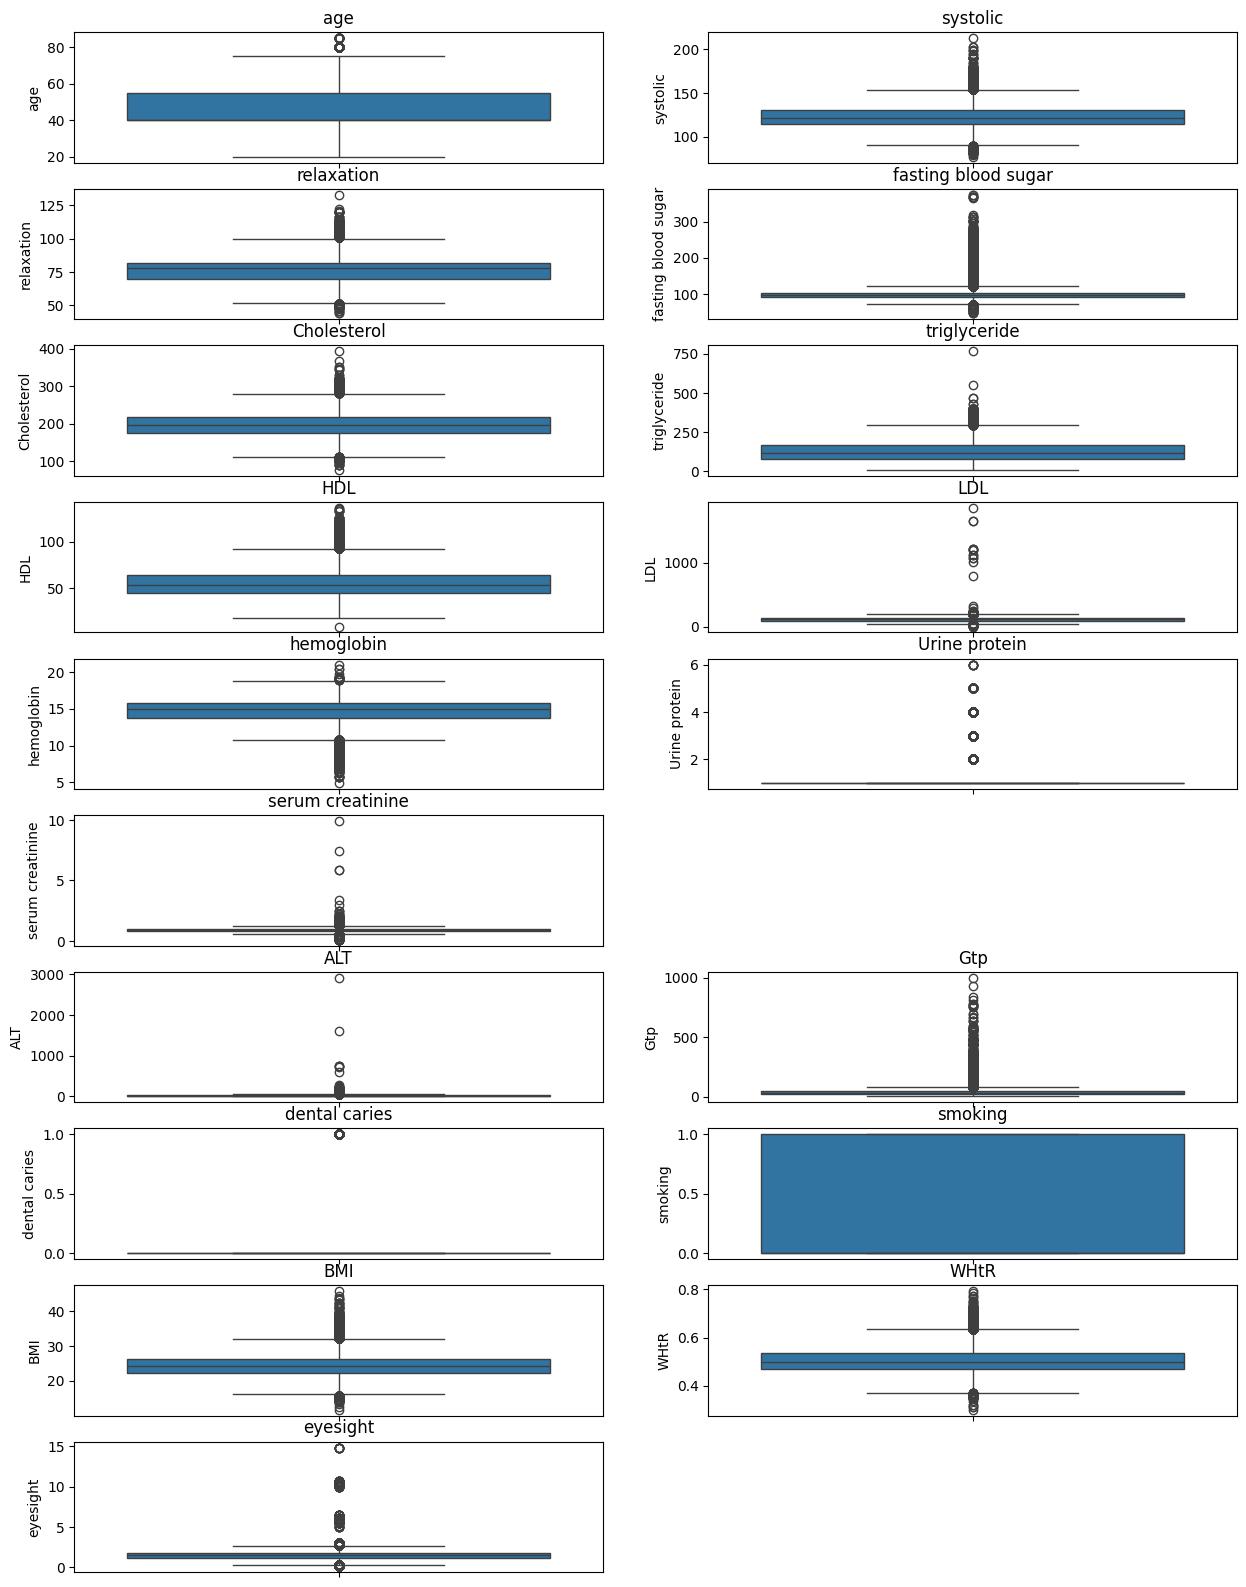

In [10]:
plt.figure(figsize=(15, 20))

for i, col in enumerate(train_df.columns):
    if i==11:
        continue
    else:
        plt.subplot(10, 2, i+1)
        sns.boxplot(train_df[col])
        plt.title(col)
        
plt.savefig('../reports/feature_boxplots.png')

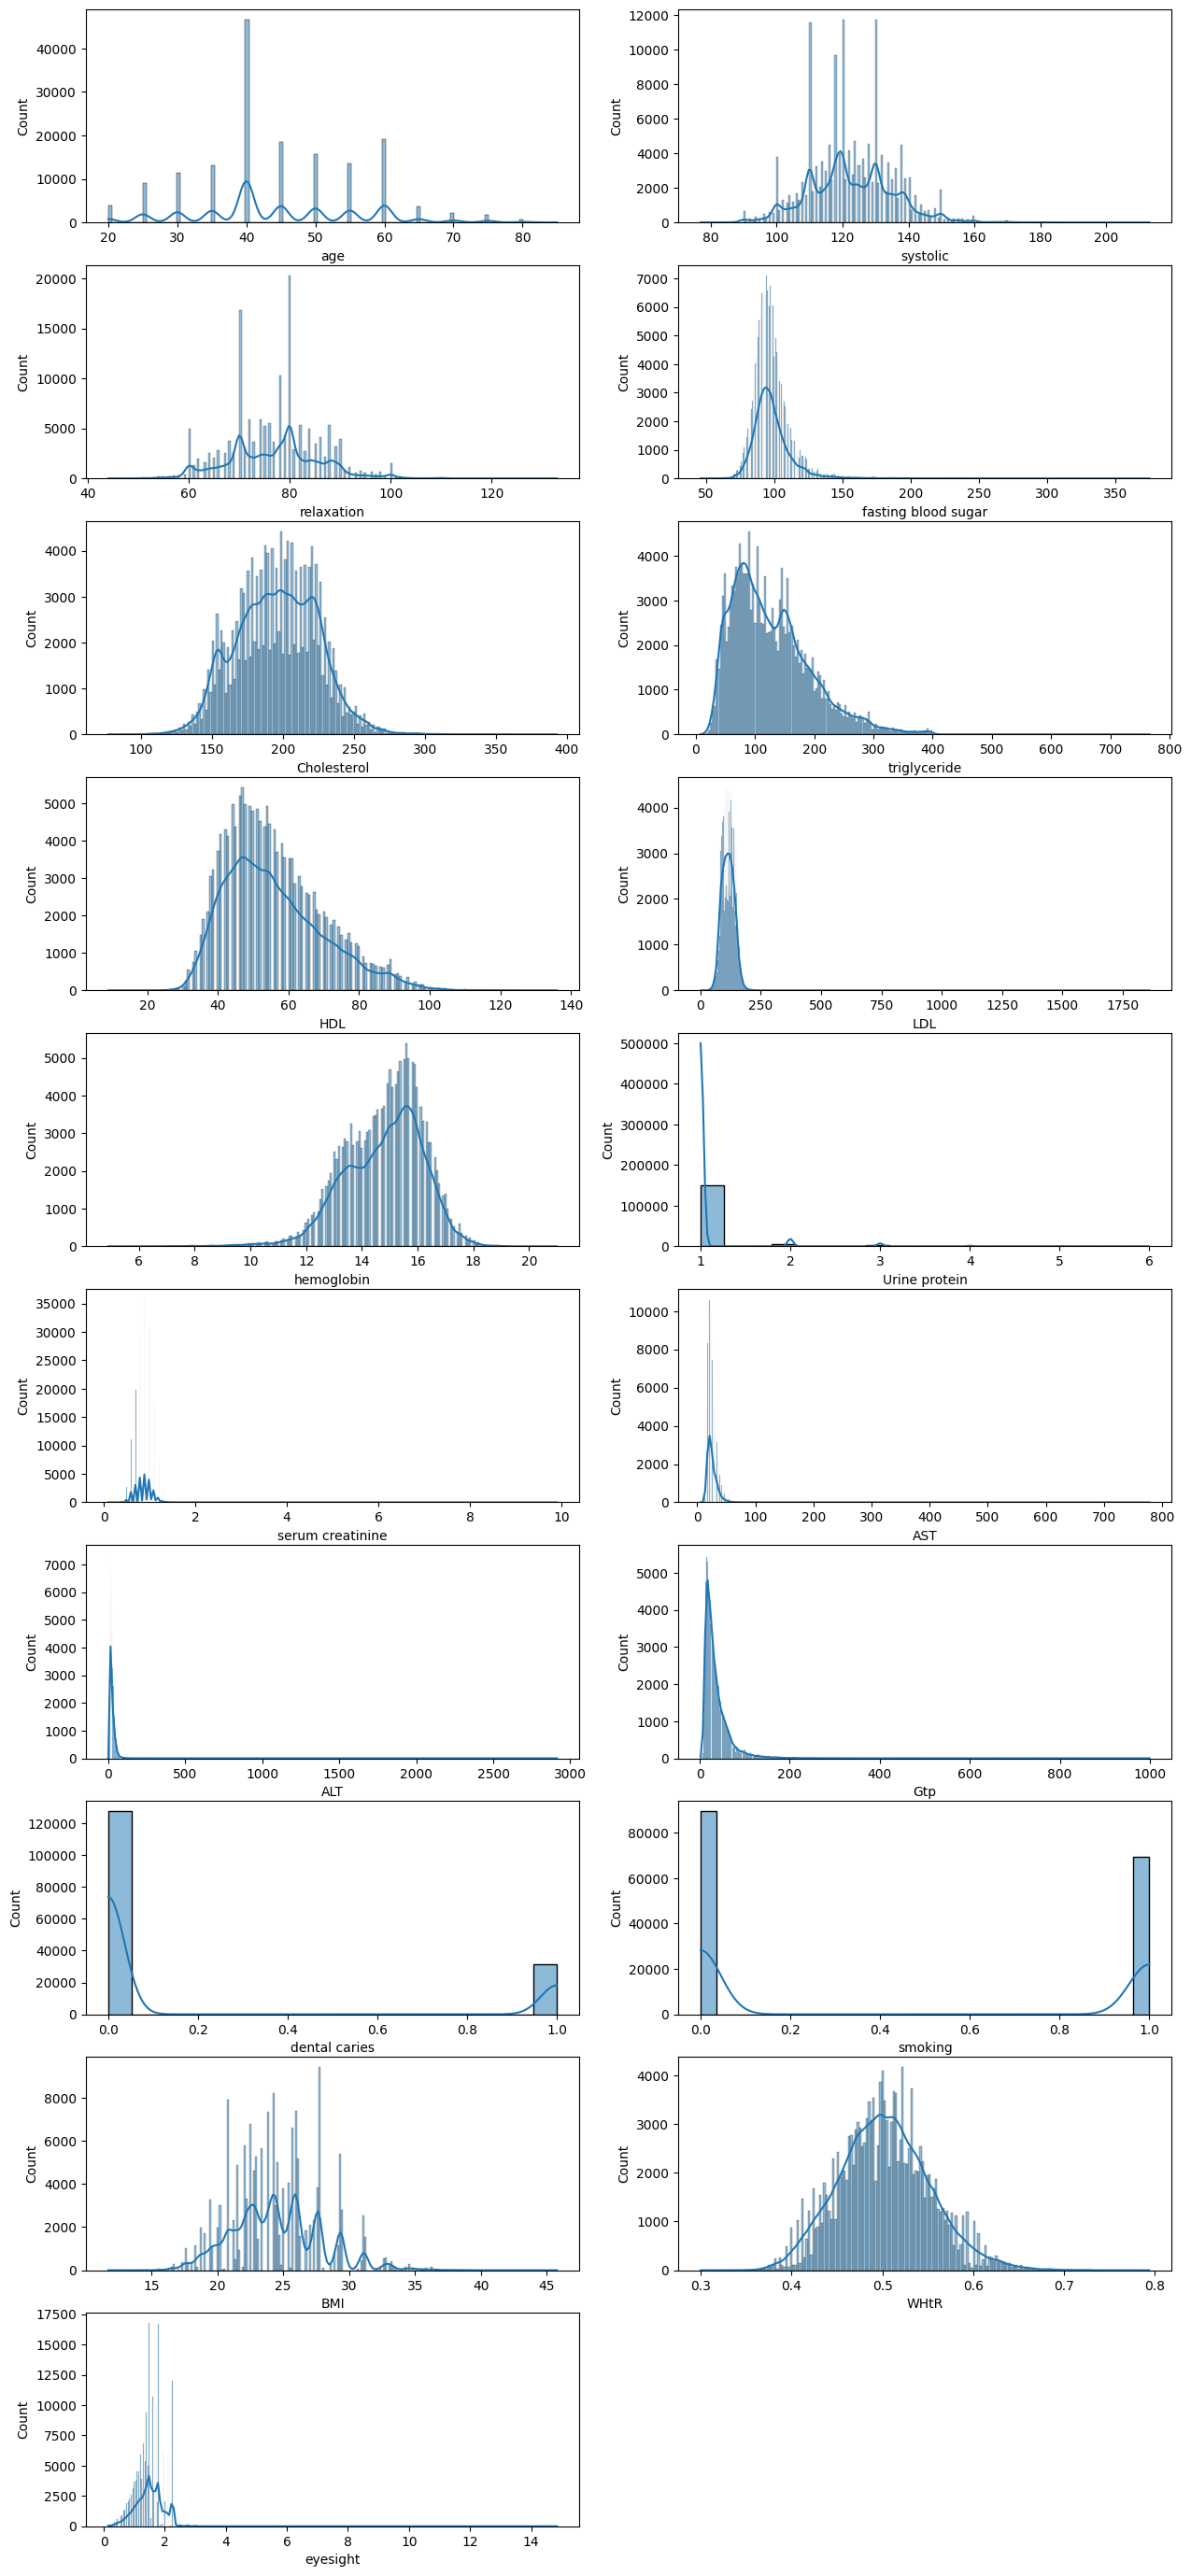

In [11]:
plt.figure(figsize=(15, 35))

for i, col in enumerate(train_df.columns):
    plt.subplot(10, 2, i+1)
    sns.histplot(train_df[col], kde=True)
        
plt.savefig('../reports/feature_histograms.png')

## Feature Scaling

In [12]:
X = train_df.drop(['smoking'], axis=1)
Y = train_df['smoking']

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train, x_val, y_train, y_val = train_test_split(X, Y, test_size=0.3, random_state=42)

In [15]:
from sklearn.preprocessing import QuantileTransformer
scaler = QuantileTransformer(output_distribution='normal', random_state=42)
scaler.set_output(transform='pandas')

x_train_scaled = scaler.fit_transform(x_train)

In [16]:
from joblib import dump

with open('../models/quantile_transformer.joblib', 'wb') as f:
    dump(scaler, f)

## Feature Selection

In [17]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFECV

In [18]:
k_best = SelectKBest(score_func=mutual_info_classif, k=15)
k_best.set_output(transform='pandas')

x_train_best = k_best.fit_transform(x_train_scaled, y_train)

In [19]:
selected_features = list(k_best.get_feature_names_out())

In [20]:
corr_matrix = train_df.corr()

In [21]:
features = dict(corr_matrix.iloc[15,:])

In [22]:
sorted_features = dict(sorted(features.items(), key=lambda item: abs(item[1]), reverse=True))

best_features = tuple(sorted_features.keys())[1:16]

In [23]:
common_best_features = set(selected_features).union(set(best_features))

In [24]:
len(common_best_features)

17

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [26]:
lr = LogisticRegression(penalty='l1', solver='liblinear', C=0.1,
                        random_state=42, n_jobs=5)

rfc = RandomForestClassifier(n_estimators=200, oob_score=True, n_jobs=None, random_state=42)

In [27]:
lr.fit(X, Y)

A:\AI-Projects\tools\miniconda3\envs\stats_ml\lib\site-packages\sklearn\linear_model\_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 5.
  warnings.warn(


LogisticRegression(C=0.1, n_jobs=5, penalty='l1', random_state=42,
                   solver='liblinear')

In [28]:
rfc.fit(X, Y)

RandomForestClassifier(n_estimators=200, oob_score=True, random_state=42)

In [29]:
from collections import defaultdict

lr_features = defaultdict(float)

for i in range(len(x_train_scaled.columns)):
    lr_features[X.columns[i]] = float(lr.coef_[0][i])

In [30]:
from collections import defaultdict

rfc_features = defaultdict(float)

for i in range(len(x_train.columns)):
    rfc_features[x_train.columns[i]] = float(rfc.feature_importances_[i])

In [31]:
lr_sorted_features = dict(sorted(dict(lr_features).items(), key=lambda item: abs(item[1]), reverse=True))
lr_best_features = tuple(lr_sorted_features.keys())[1:16]

In [32]:
rfc_sorted_features = dict(sorted(dict(rfc_features).items(), key=lambda item: abs(item[1]), reverse=True))
rfc_best_features = tuple(rfc_sorted_features.keys())[1:16]

In [33]:
model_best_features = set(lr_best_features).union(set(rfc_best_features))

In [34]:
len(model_best_features)

18

In [35]:
robust_features = list(common_best_features.intersection(model_best_features))

In [36]:
len(robust_features)

17

In [37]:
from sklearn.model_selection import StratifiedKFold

In [38]:
estimator = LogisticRegression(penalty='l1', C=0.1, random_state=42, solver='saga', 
                                n_jobs=5, max_iter=1000, verbose=1)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

rfecv = RFECV(estimator=estimator, step=1, min_features_to_select=10, cv=cv, 
              scoring='f1', verbose=2, n_jobs=5, importance_getter='auto')

rfecv.set_output(transform='pandas')

RFECV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
      estimator=LogisticRegression(C=0.1, max_iter=1000, n_jobs=5, penalty='l1',
                                   random_state=42, solver='saga', verbose=1),
      min_features_to_select=10, n_jobs=5, scoring='f1', verbose=2)

In [ ]:
rfecv.fit(x_train, y_train)

In [ ]:
rfecv.ranking_

In [ ]:
rfecv.n_features_

In [ ]:
x_scaled.columns

## Model Training

In [ ]:
x_train_scaled.shape

In [ ]:
x_train.shape

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
lr = LogisticRegression(penalty='elasticnet', C=1.0, solver='saga', l1_ratio=0.5,
                        random_state=42, max_iter=10000, n_jobs=5)

dtc = DecisionTreeClassifier(random_state=42)

rfc = RandomForestClassifier(n_estimators=500, bootstrap=True, oob_score=True, 
                             n_jobs=5, random_state=42, verbose=1)

In [ ]:
lr.fit(x_train_scaled, y_train)
dtc.fit(x_train, y_train)
rfc.fit(x_train, y_train)

## Model Validation

In [ ]:
x_val_scaled = scaler.transform(x_val)

In [ ]:
# validating models
lr_preds = lr.predict(x_val_scaled)
dtc_preds = dtc.predict(x_val)
rfc_preds = rfc.predict(x_val)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
print(f'Accuracy: {round(accuracy_score(y_val, lr_preds), 4) * 100} %')
print(f'Accuracy: {round(accuracy_score(y_val, dtc_preds), 4) * 100} %')
print(f'Accuracy: {round(accuracy_score(y_val, rfc_preds), 4) * 100} %')

In [ ]:
print(f'F1 Score: {round(f1_score(y_val, lr_preds), 2)}')
print(f'F1 Score: {round(f1_score(y_val, rfc_preds), 2)}')
print(f'F1 Score: {round(f1_score(y_val, dtc_preds), 2)}')

## Model Testing

In [35]:
from joblib import dump

with open('../models/logistic_regression.joblib', 'wb') as f:
    dump(lr, f)

with open('../models/decision_tree_classifier.joblib', 'wb') as f:
    dump(dtc, f)

with open('../models/random_forest_classifier.joblib', 'wb') as f:
    dump(rfc, f)


In [36]:
from sklearn.metrics import confusion_matrix

In [37]:
lr_cm = confusion_matrix(y_val, lr_preds)
dtc_cm = confusion_matrix(y_val, dtc_preds)
rfc_cm = confusion_matrix(y_val, rfc_preds)

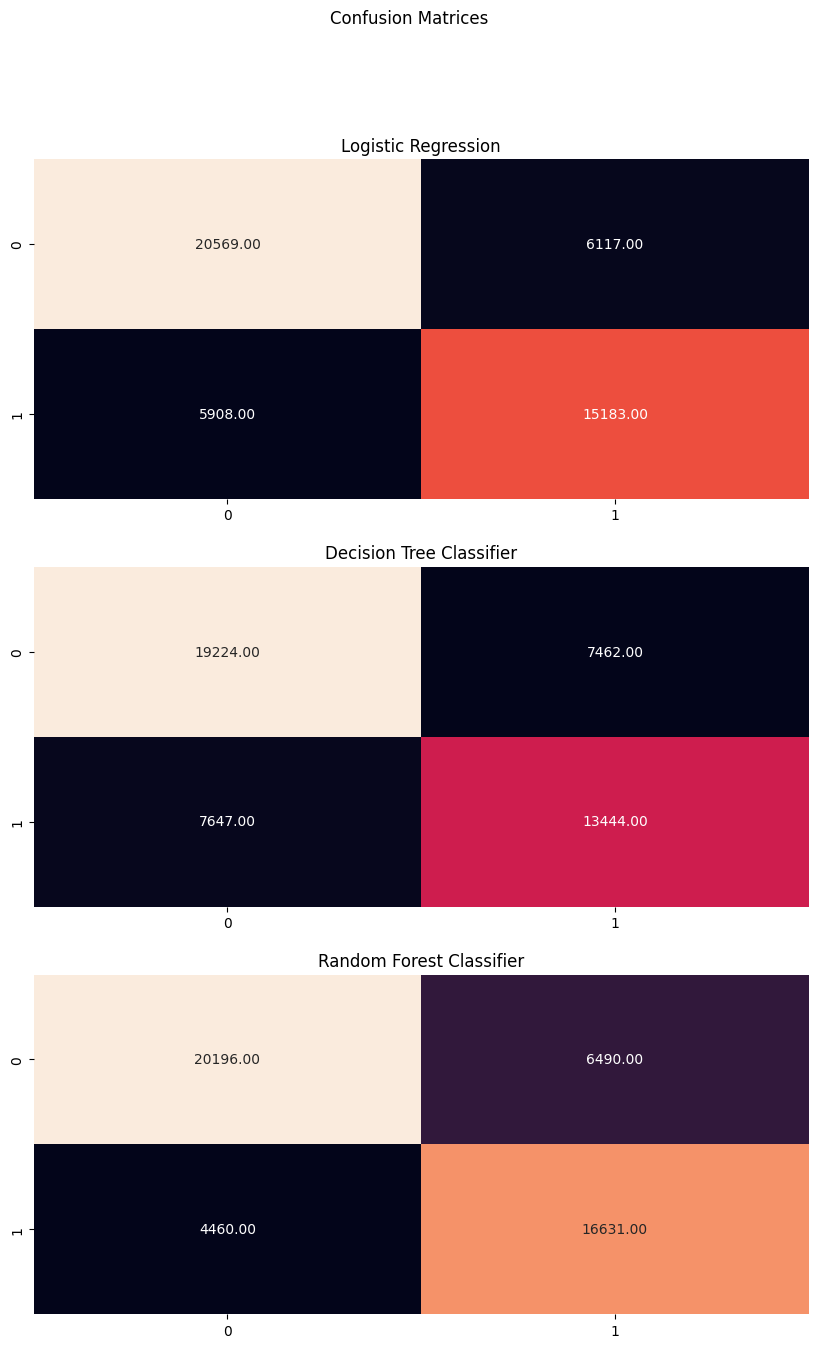

In [38]:
fig, ax = plt.subplots(3,1, figsize=(10, 15))
fig.suptitle('Confusion Matrices')

plt.subplot(3, 1, 1)
sns.heatmap(lr_cm, annot=True, cbar=False, fmt='.2f')
plt.title('Logistic Regression')

plt.subplot(3, 1, 2)
sns.heatmap(dtc_cm, annot=True, cbar=False, fmt='.2f')
plt.title('Decision Tree Classifier')

plt.subplot(3, 1, 3)
sns.heatmap(rfc_cm, annot=True, cbar=False, fmt='.2f')
plt.title('Random Forest Classifier')


plt.savefig('../reports/Confusion_Matrices.png')

In [39]:
from sklearn.metrics import auc, roc_curve, precision_recall_curve

In [41]:
lr_score = lr.predict_proba(x_val_scaled)[:, 1]

In [52]:
rfc_score = rfc.predict_proba(x_val)[:, 1]

[Parallel(n_jobs=5)]: Using backend ThreadingBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done  40 tasks      | elapsed:    0.1s
[Parallel(n_jobs=5)]: Done 190 tasks      | elapsed:    0.7s
[Parallel(n_jobs=5)]: Done 440 tasks      | elapsed:    1.7s
[Parallel(n_jobs=5)]: Done 600 out of 600 | elapsed:    2.3s finished


In [53]:
lr_fpr, lr_tpr, lr_thresholds = roc_curve(y_val, lr_score, pos_label=1)

In [54]:
lr_auc = auc(lr_fpr, lr_tpr)

In [57]:
rfc_fpr, rfc_tpr, rfc_thresholds = roc_curve(y_val, rfc_score, pos_label=1)

In [58]:
rfc_auc = auc(rfc_fpr, rfc_tpr)

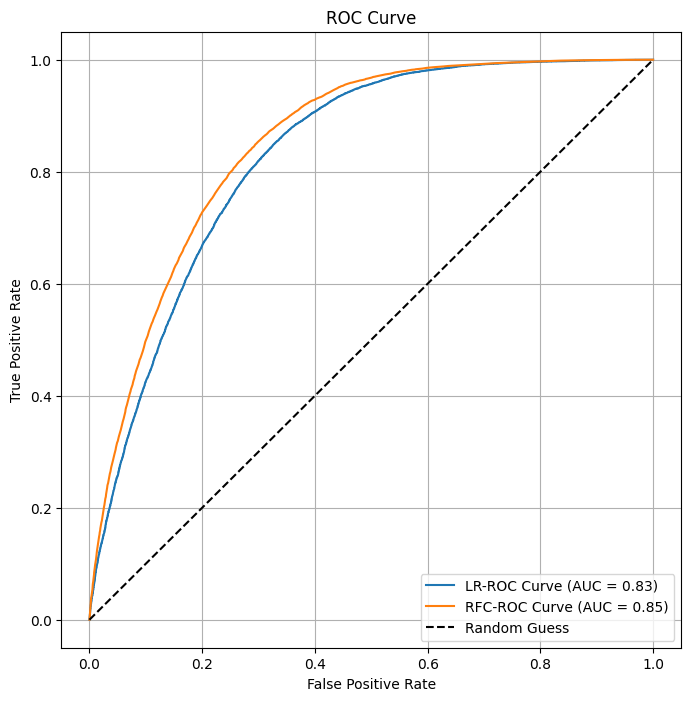

In [61]:
plt.figure(figsize=(8, 8))
plt.plot(lr_fpr, lr_tpr, label=f'LR-ROC Curve (AUC = {lr_auc:.2f})')
plt.plot(rfc_fpr, rfc_tpr, label=f'RFC-ROC Curve (AUC = {rfc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve")
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('../models/ROC_Curves.png')

In [62]:
lr_pre, lr_rec, thresholds = precision_recall_curve(y_val, lr_score)

In [63]:
rfc_pre, rfc_rec, thresholds = precision_recall_curve(y_val, rfc_score)

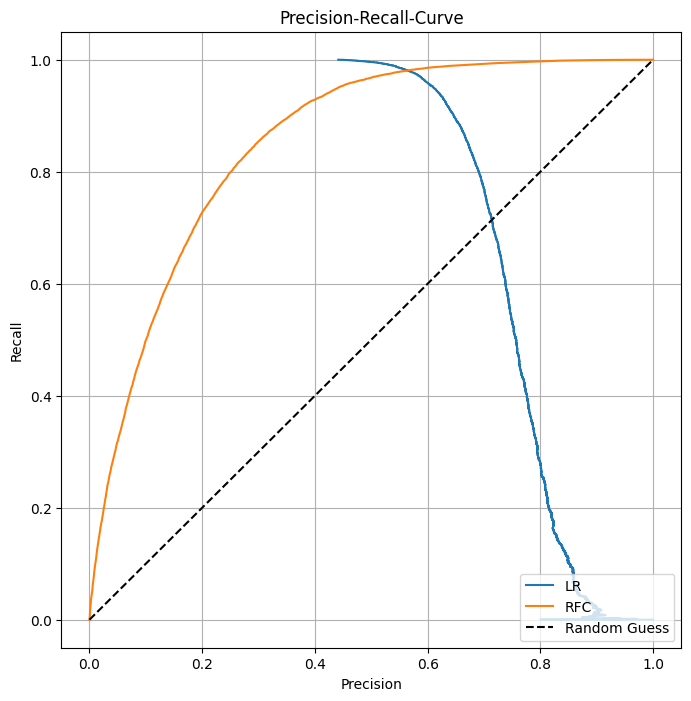

In [66]:
plt.figure(figsize=(8, 8))
plt.plot(lr_pre, lr_rec, label=f'LR')
plt.plot(rfc_fpr, rfc_tpr, label=f'RFC')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('Precision')
plt.ylabel('Recall')
plt.title("Precision-Recall-Curve")
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('../models/Precision_Recall_Curves.png')